# 🛒 Online Retail Data Cleaning Project

## Objective
Clean and prepare an e-commerce dataset for analysis using Python (Pandas).

## Tools Used
- Python (Pandas)
- Jupyter Notebook

## Dataset
Online Retail Dataset (UCI / Kaggle)

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("D:/DSML/Online Retail dataset/data/cleaned_online_retail.xlsx")
df.head()

,InvoiceNo,StockCode,Clean_Description,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,15.30,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,22.00,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom


In [3]:
df.shape

(38558, 9)

## 🔍 Understanding Dataset Structure
Checking data types and non-null values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38558 entries, 0 to 38557
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   InvoiceNo          38558 non-null  int64         
 1   StockCode          38558 non-null  object        
 2   Clean_Description  38558 non-null  object        
 3   Quantity           38558 non-null  int64         
 4   InvoiceDate        38558 non-null  datetime64[ns]
 5   UnitPrice          38558 non-null  float64       
 6   TotalPrice         38558 non-null  float64       
 7   CustomerID         38558 non-null  int64         
 8   Country            38558 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 2.6+ MB


In [5]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerID
count,38558.000000,38558.000000,38558,38558.000000,38558.000000,38558.000000
mean,538956.129753,14.812672,2010-12-21 02:08:30.698687744,3.133462,25.416517,15383.217983
min,536365.000000,1.000000,2010-12-01 08:26:00,0.070000,0.140000,12346.000000
25%,537467.000000,2.000000,2010-12-07 10:36:00,1.250000,4.950000,13993.000000
50%,538852.000000,5.000000,2010-12-14 13:33:00,1.950000,11.800000,15358.000000
75%,540415.000000,12.000000,2011-01-07 10:47:00,3.750000,19.800000,17033.000000
max,541686.000000,74215.000000,2011-01-20 15:42:00,295.000000,77183.600000,18283.000000
std,1580.893030,381.112275,NaN,5.286768,404.356770,1771.072244


In [6]:
df.isnull().sum()

InvoiceNo            0
StockCode            0
Clean_Description    0
Quantity             0
InvoiceDate          0
UnitPrice            0
TotalPrice           0
CustomerID           0
Country              0
dtype: int64

## 🧹 Data Cleaning
- Removing duplicates
- Handling missing values
- Fixing data types

In [7]:
df = df.drop_duplicates()

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## ⚙️ Feature Engineering
Creating new useful columns like Month, Year, and Total Check.

In [9]:
df['Month'] = df['InvoiceDate'].dt.month

In [10]:
df['Year'] = df['InvoiceDate'].dt.year

In [11]:
df['Check_Total'] = df['Quantity'] * df['UnitPrice']

In [12]:
df['Mismatch'] = df['TotalPrice'] - df['Check_Total']
df['Mismatch'].abs().sum()

np.float64(0.0)

## ✅ Data Validation
Checked if TotalPrice matches Quantity × UnitPrice.
No major inconsistencies found.

In [13]:
df.head(10)

,InvoiceNo,StockCode,Clean_Description,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerID,Country,Month,Year,Check_Total,Mismatch
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,15.30,17850,United Kingdom,12,2010,15.30,0.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom,12,2010,20.34,0.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,22.00,17850,United Kingdom,12,2010,22.00,0.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom,12,2010,20.34,0.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,20.34,17850,United Kingdom,12,2010,20.34,0.0
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,15.30,17850,United Kingdom,12,2010,15.30,0.0
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,25.50,17850,United Kingdom,12,2010,25.50,0.0
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,11.10,17850,United Kingdom,12,2010,11.10,0.0
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,11.10,17850,United Kingdom,12,2010,11.10,0.0
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,54.08,13047,United Kingdom,12,2010,54.08,0.0


In [14]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head()

Country
United Kingdom    819196.34
EIRE               29069.02
Netherlands        27200.86
Germany            23059.00
France             21943.93
Name: TotalPrice, dtype: float64

In [15]:
df.groupby('Year')['TotalPrice'].sum()

Year
2010    570422.73
2011    409587.33
Name: TotalPrice, dtype: float64

In [16]:
df.groupby('Month')['TotalPrice'].sum()

Month
1     409587.33
12    570422.73
Name: TotalPrice, dtype: float64

In [17]:
df.to_csv("final_cleaned_online_retail.csv", index=False)

## Simple Visualization

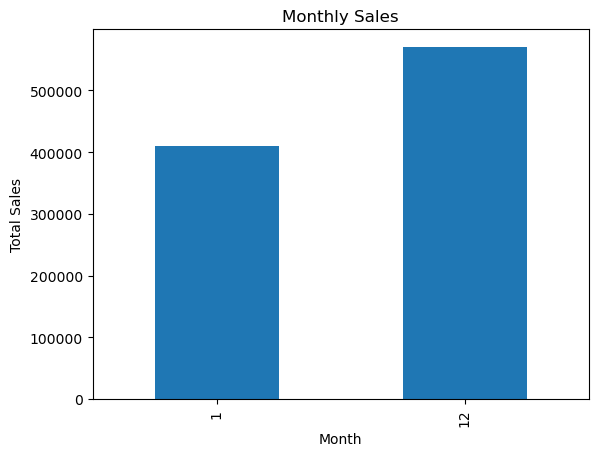

In [18]:
import matplotlib.pyplot as plt

df.groupby('Month')['TotalPrice'].sum().plot(kind='bar')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.savefig('monthly_sales.png', dpi=300, bbox_inches='tight')  # ✅ Save here
plt.show()

## 📊 Key Insights

- Sales are significantly higher in December compared to January.
- This indicates strong seasonal demand during the holiday season.
- Businesses can leverage this trend by increasing inventory and marketing efforts in Q4.
- Dataset appears to contain limited monthly coverage (only January and December).